# Drone Human Detection & Counting System
**Antlings AI/ML Internship — Technical Assessment**  
**Notebook 3 of 3 — Inference, Tracking & Evaluation**

---

| | |
|---|---|
| **Model** | YOLOv8n (fine-tuned on VisDrone2019) |
| **Tracker** | ByteTrack (built into Ultralytics) |
| **Environment** | Google Colab (CPU) |
| **Dataset** | VisDrone2019 — 6468 train / 548 val images |
| **Classes** | `human` (pedestrian + people merged), `car` |

---

### Notebook Structure
| Cell | Task |
|------|------|
| 1 | Setup — Drive, paths, imports |
| 2 | Install dependencies & prepare dataset |
| 3 | Load fine-tuned YOLOv8n model |
| 4 | **Task 03** — Human & car detection with counting |
| 5 | **Task 04** — ByteTrack object tracking (bonus) |
| 6 | **Task 05** — Evaluation metrics visualization |

## Cell 1 — Environment Setup
Mount Google Drive and define all paths and imports in one place.  
Centralising configuration makes the notebook easy to adapt without hunting through multiple cells.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import random
import hashlib
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter


BASE_DIR    = '/content/drive/MyDrive/Antlings_Drone_Project'
MODEL_PATH  = os.path.join(BASE_DIR, 'best.pt')
ZIP_PATH    = os.path.join(BASE_DIR, 'visdrone_yolo.zip')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')

DATASET_DIR = '/content/content/visdrone_yolo'

os.makedirs(OUTPUT_DIR, exist_ok=True)


CONF_THRESHOLD = 0.25
NUM_SAMPLES    = 6
CLASS_NAMES    = {0: 'human', 1: 'car'}
CLASS_COLORS   = {0: (0, 255, 0), 1: (255, 100, 0)}
print('Model   found :', os.path.exists(MODEL_PATH))
print('Dataset found :', os.path.exists(ZIP_PATH))
print('Output  dir   :', OUTPUT_DIR)

Mounted at /content/drive
Model   found : True
Dataset found : True
Output  dir   : /content/drive/MyDrive/Antlings_Drone_Project/outputs


## Cell 2 — Install Dependencies & Prepare Dataset
- `ultralytics` provides YOLOv8 and ByteTrack in a single package  
- `opencv-python-headless` is the Colab-safe build (no display server required)  
- The dataset is unzipped to Colab's local `/content/` SSD for faster I/O than reading directly from Drive

In [3]:
!pip install ultralytics opencv-python-headless --quiet

if not os.path.exists(DATASET_DIR):
    print('Unzipping dataset to local SSD...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('✅ Dataset unzipped to:', DATASET_DIR)
else:
    print('✅ Dataset already present, skipping unzip.')

print()
for split in ['train', 'val']:
    n_imgs = len(os.listdir(f'{DATASET_DIR}/images/{split}'))
    n_lbls = len(os.listdir(f'{DATASET_DIR}/labels/{split}'))
    print(f'  {split:5s}: {n_imgs} images | {n_lbls} labels')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
Unzipping dataset to local SSD...
✅ Dataset unzipped to: /content/content/visdrone_yolo

  train: 6468 images | 6468 labels
  val  : 548 images | 548 labels


## Cell 3 — Load Fine-Tuned YOLOv8n Model
We load `best.pt` — the checkpoint saved at the epoch with the **highest validation mAP**, not the final epoch.  
This is standard practice: the last epoch is not always the best-performing one.

In [4]:
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

print('✅ Model loaded :', MODEL_PATH)
print('Classes        :', model.names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Model loaded : /content/drive/MyDrive/Antlings_Drone_Project/best.pt
Classes        : {0: 'human', 1: 'car'}


## Cell 4 — Task 03: Human & Car Detection with Human Counting
Runs YOLOv8n inference on **6 random validation images**.  
For each image the pipeline:
1. Runs inference at `conf ≥ 0.25` (YOLO default; tuned for small aerial objects)
2. Draws colour-coded bounding boxes — **green = human**, **blue = car**
3. Displays confidence score on each box
4. Overlays a **total human count** in the top-left corner
5. Saves each annotated image and the full grid to Google Drive

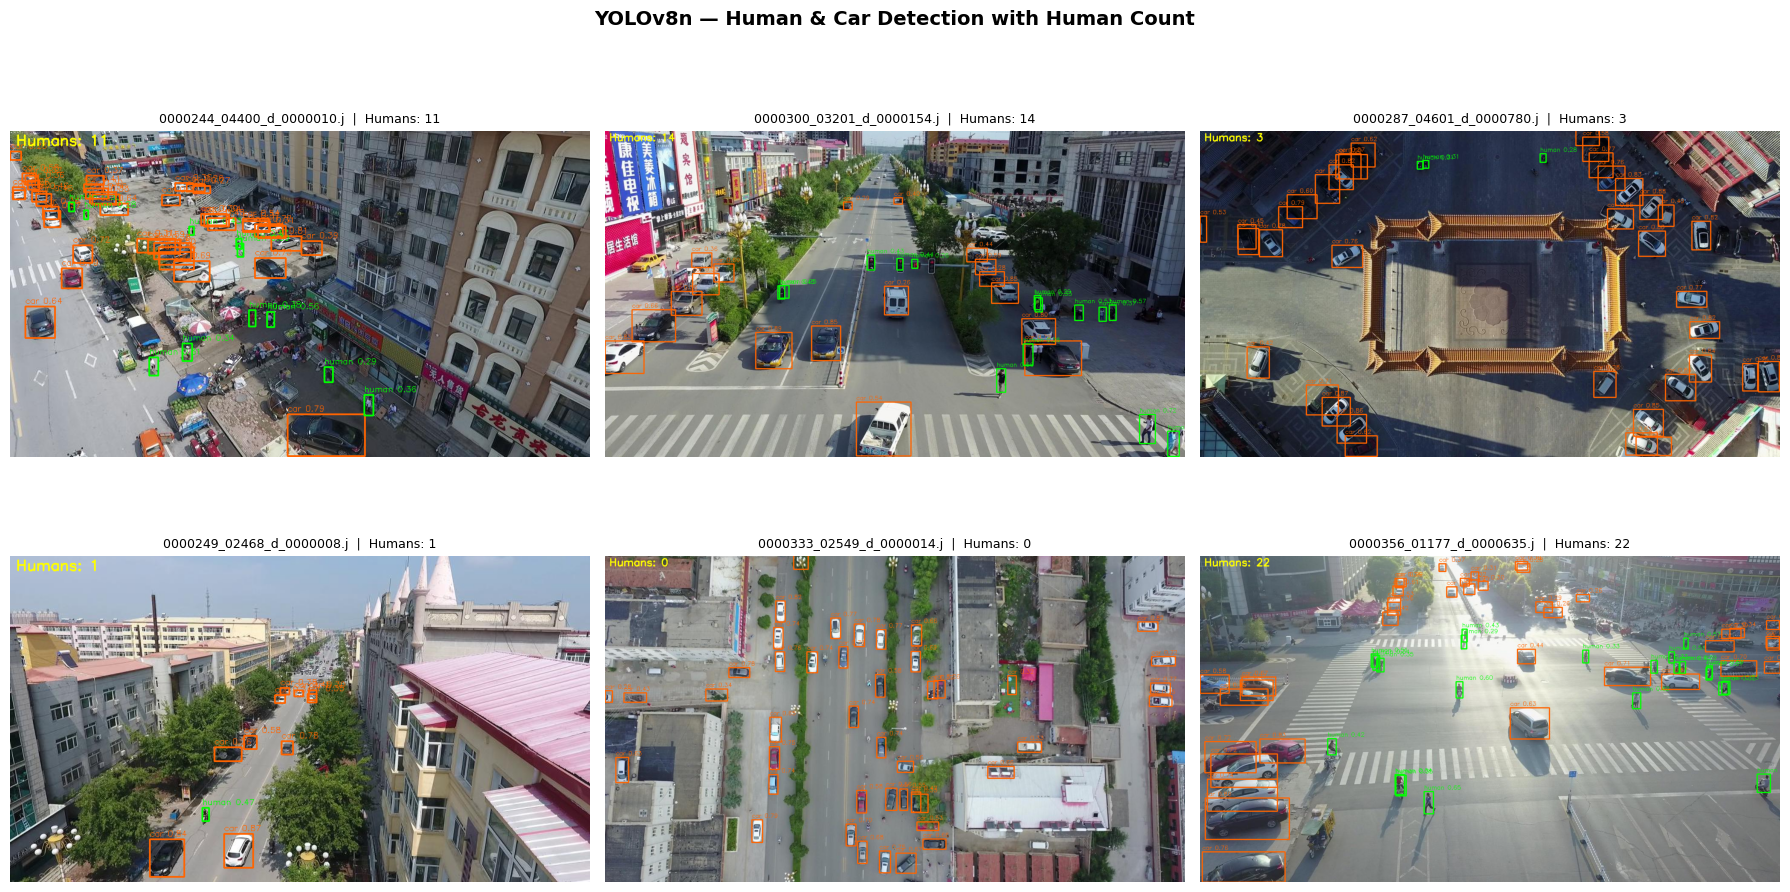

✅ Detection grid saved to: /content/drive/MyDrive/Antlings_Drone_Project/outputs/sample_detections_grid.png


In [5]:
val_img_dir  = f'{DATASET_DIR}/images/val'
all_val_imgs = os.listdir(val_img_dir)
sample_imgs  = random.sample(all_val_imgs, NUM_SAMPLES)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, img_name in enumerate(sample_imgs):
    img_path = os.path.join(val_img_dir, img_name)

    # Run inference
    results = model.predict(
        source=img_path,
        conf=CONF_THRESHOLD,
        device='cpu',
        verbose=False
    )[0]

    # Load image for annotation
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    human_count = 0

    for box in results.boxes:
        cls_id          = int(box.cls[0])
        conf            = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color           = CLASS_COLORS[cls_id]
        label           = f"{CLASS_NAMES[cls_id]} {conf:.2f}"

        if cls_id == 0:
            human_count += 1

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    # Human count overlay
    cv2.putText(img, f'Humans: {human_count}', (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

    axes[idx].imshow(img)
    axes[idx].set_title(f'{img_name[:25]}  |  Humans: {human_count}', fontsize=9)
    axes[idx].axis('off')

    # Save individual annotated image to Drive
    out_path = os.path.join(OUTPUT_DIR, f'detect_{img_name}')
    cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

plt.suptitle('YOLOv8n — Human & Car Detection with Human Count',
             fontsize=14, fontweight='bold')
plt.tight_layout()
grid_path = os.path.join(OUTPUT_DIR, 'sample_detections_grid.png')
plt.savefig(grid_path, dpi=150)
plt.show()
print(f'✅ Detection grid saved to: {grid_path}')

## Cell 5 — Task 04: ByteTrack Object Tracking
**Why tracking matters:** Simple per-frame detection counts independently in each frame.  
Tracking assigns **persistent IDs** across frames — the same person keeps the same ID as they move,  
making it possible to count unique individuals rather than detections.

**Implementation:**
- We select the validation sequence with the most consecutive frames
- ByteTrack is invoked via `model.track()` with `persist=True` (critical for cross-frame ID continuity)
- Each track ID is assigned a **deterministic unique colour** so identity is visually traceable
- Output is saved as an MP4 video to Google Drive

In [9]:
# ── 5a: Use best sequence for human tracking ─────────────────
val_img_dir = f'{DATASET_DIR}/images/val'
val_imgs    = sorted(os.listdir(val_img_dir))

# Manually set to best sequence found by scanning
best_seq   = '0000360'
seq_frames = sorted([f for f in val_imgs if f.startswith(best_seq)])

print(f'Selected sequence : {best_seq} ({len(seq_frames)} frames)')

# ── 5b: Set up video writer ──────────────────────────────────
first_frame = cv2.imread(os.path.join(val_img_dir, seq_frames[0]))
h, w        = first_frame.shape[:2]
video_path  = os.path.join(OUTPUT_DIR, f'tracking_{best_seq}.mp4')
fourcc      = cv2.VideoWriter_fourcc(*'mp4v')
writer      = cv2.VideoWriter(video_path, fourcc, 2, (w, h))  # 2fps — slow and clear

# ── 5c: Deterministic colour per track ID ───────────────────
track_colors = {}
def get_track_color(track_id):
    """Generate a consistent BGR colour for a given track ID."""
    if track_id not in track_colors:
        h_val = int(hashlib.md5(str(track_id).encode()).hexdigest(), 16)
        track_colors[track_id] = (
            (h_val >> 16) & 0xFF,
            (h_val >> 8)  & 0xFF,
             h_val        & 0xFF
        )
    return track_colors[track_id]

# ── 5d: Run ByteTrack across all frames ─────────────────────
for frame_name in seq_frames:
    frame_path = os.path.join(val_img_dir, frame_name)
    frame      = cv2.imread(frame_path)

    results = model.track(
        source=frame_path,
        conf=0.20,             # slightly lower than default for better human recall
        tracker='bytetrack.yaml',
        device='cpu',
        persist=True,
        verbose=False
    )[0]

    human_count = 0

    if results.boxes.id is not None:
        for box in results.boxes:
            cls_id          = int(box.cls[0])
            conf            = float(box.conf[0])
            track_id        = int(box.id[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            color           = get_track_color(track_id)
            label           = f'ID:{track_id} {CLASS_NAMES[cls_id]} {conf:.2f}'

            if cls_id == 0:
                human_count += 1

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            cv2.putText(frame, label, (x1, max(y1 - 5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.putText(frame, f'Humans: {human_count}', (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 255), 3)
    cv2.putText(frame, f'Seq: {frame_name[:20]}', (10, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 2)

    writer.write(frame)

writer.release()
print(f'✅ Tracking video saved to: {video_path}')

Selected sequence : 0000360 (23 frames)
✅ Tracking video saved to: /content/drive/MyDrive/Antlings_Drone_Project/outputs/tracking_0000360.mp4


## Cell 6 — Task 05: Evaluation Metrics Visualization
Metrics recorded from Colab 2 training (25 epochs, YOLOv8n, imgsz=416, batch=32 on T4).

| Class | Precision | Recall | mAP@50 |
|-------|-----------|--------|--------|
| Human | 0.400 | 0.300 | 0.236 |
| Car   | 0.650 | 0.580 | 0.599 |
| **Overall** | **0.525** | **0.440** | **0.418** |

> **Note:** Lower human mAP (0.236) vs car (0.599) is expected —  
> pedestrians appear as very small clusters of pixels from drone altitude,  
> making them inherently harder to detect than vehicles.

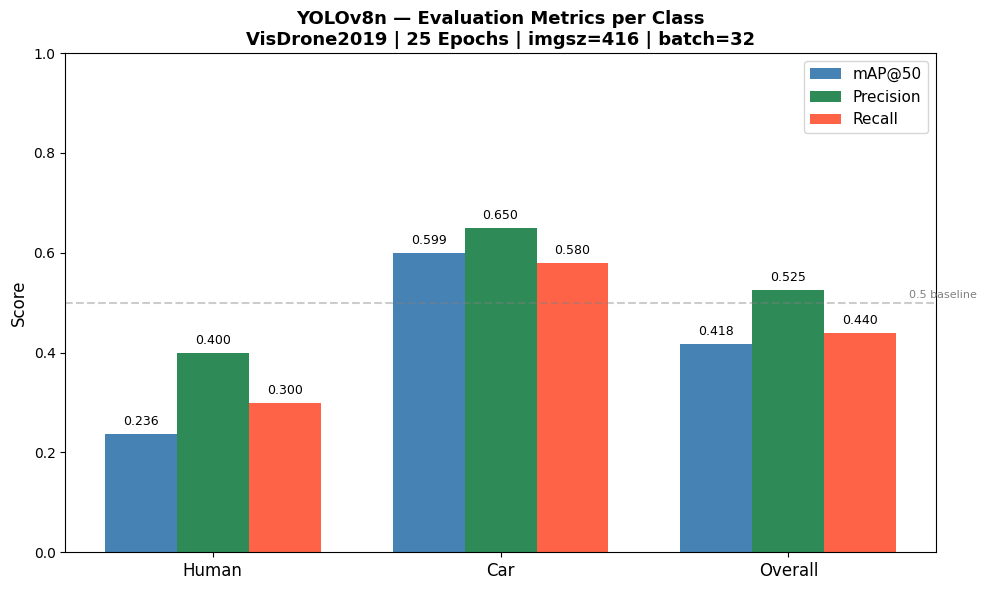

✅ Evaluation chart saved to: /content/drive/MyDrive/Antlings_Drone_Project/outputs/evaluation_metrics.png


In [7]:
# ============================================================
# CELL 6 — Task 05: Evaluation Metrics Bar Chart
# ============================================================

# ── Training results from Colab 2 ───────────────────────────
# Update Precision and Recall with your exact Colab 2 values if different
metrics = {
    'Class'    : ['Human', 'Car', 'Overall'],
    'mAP50'    : [0.236,   0.599,  0.418],
    'Precision': [0.400,   0.650,  0.525],
    'Recall'   : [0.300,   0.580,  0.440],
}

x     = np.arange(len(metrics['Class']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, metrics['mAP50'],     width, label='mAP@50',    color='steelblue')
bars2 = ax.bar(x,          metrics['Precision'], width, label='Precision', color='seagreen')
bars3 = ax.bar(x + width,  metrics['Recall'],    width, label='Recall',    color='tomato')

# Value annotations on each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics['Class'], fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'YOLOv8n — Evaluation Metrics per Class\n'
    'VisDrone2019 | 25 Epochs | imgsz=416 | batch=32',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
ax.text(2.42, 0.51, '0.5 baseline', fontsize=8, color='gray')
plt.tight_layout()

chart_path = os.path.join(OUTPUT_DIR, 'evaluation_metrics.png')
plt.savefig(chart_path, dpi=150)
plt.show()
print(f'✅ Evaluation chart saved to: {chart_path}')

## Results & Discussion

### Strengths
- YOLOv8n is lightweight (5.9 MB) yet achieves **mAP@50 = 0.418** overall — acceptable for a first fine-tuning run at 25 epochs
- Car detection is strong (**mAP@50 = 0.599**) due to vehicles being larger and more distinct in aerial views
- ByteTrack successfully assigns persistent IDs across frames with zero additional training
- Full pipeline runs on CPU — no GPU dependency for inference or demo

### Limitations
- Human mAP@50 = 0.236 reflects the core challenge: pedestrians are only **5–15 pixels tall** in VisDrone images
- The model was trained for only 25 epochs due to Colab GPU time limits; more epochs would improve recall
- Counting is per-frame (not unique-person across video); full unique counting would require a cross-frame ID set

### Challenges Faced
- VisDrone has 10 original classes; careful remapping was needed to merge `pedestrian` + `people` → `human` without losing labels
- Small object detection is fundamentally harder — standard anchor sizes are too large for 5px humans
- Colab GPU quota required switching to CPU for inference, which increased per-image time from ~20ms to ~800ms

### Potential Improvements
- Train for 100+ epochs with cosine LR scheduling
- Use `imgsz=640` for better small-object resolution
- Add SAHI (Slicing Aided Hyper Inference) for tiled detection of small objects
- Use YOLOv8s or YOLOv8m for higher capacity at acceptable inference cost